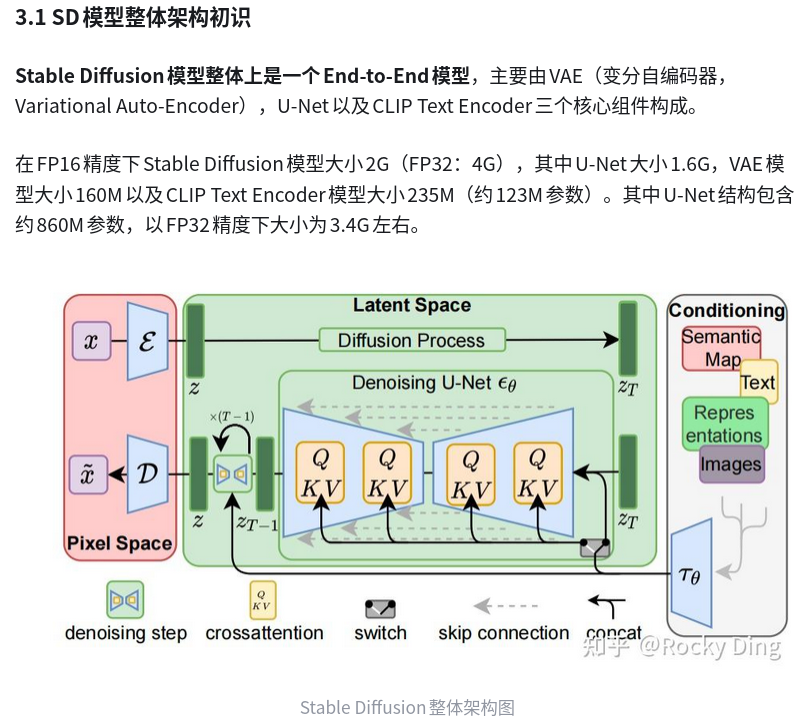

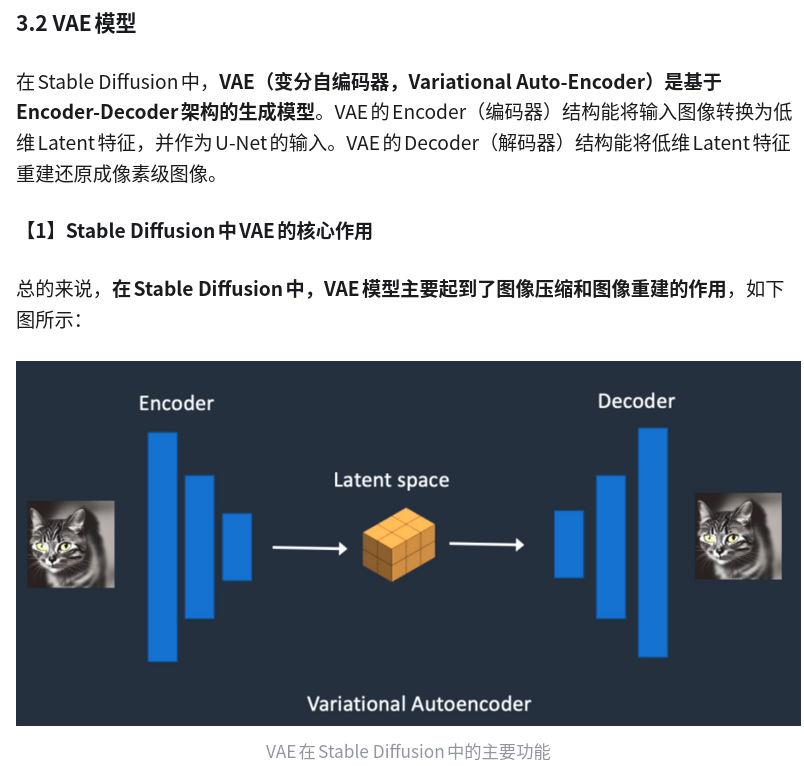

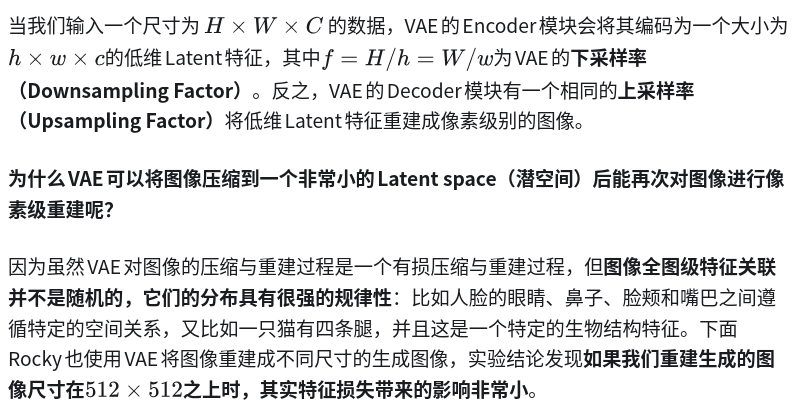

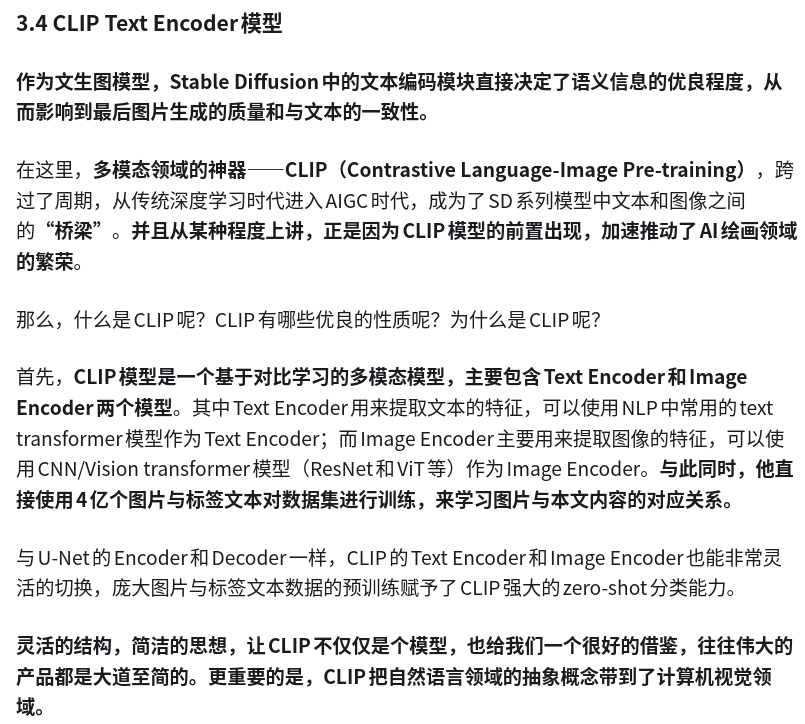

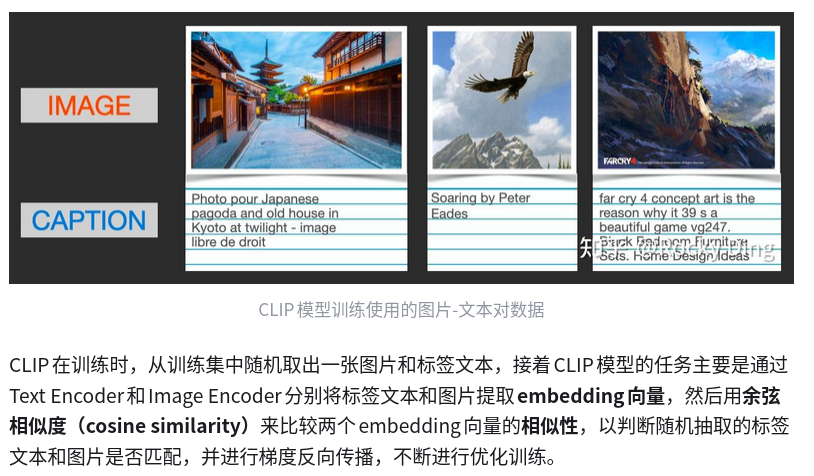

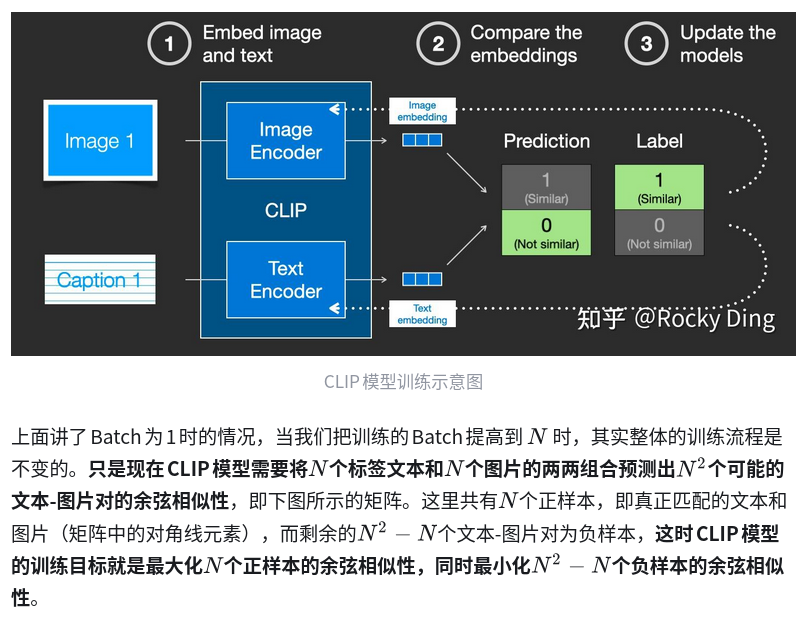

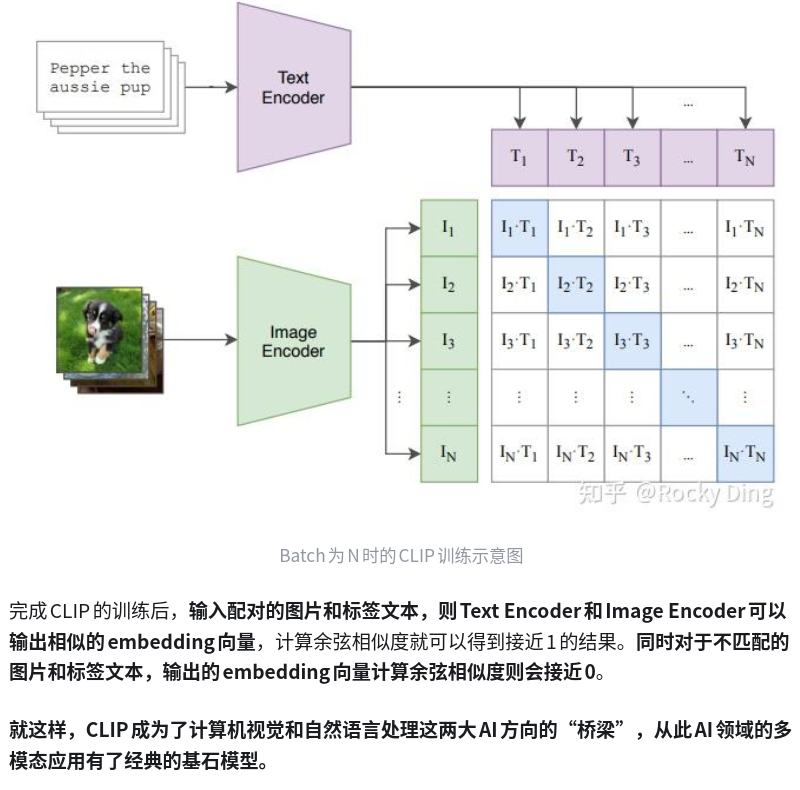

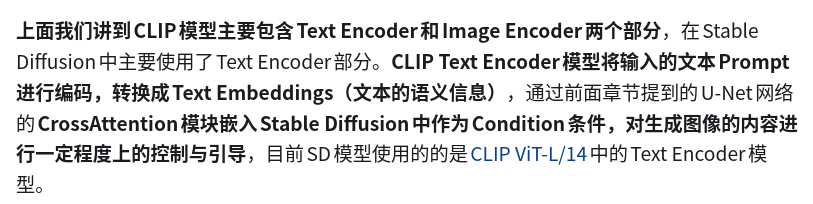

## 6. Stable Diffusion

到目前为止，这份笔记解释的是当前仓库的真实实现：它是 **带类别条件的像素空间 DDPM**。这类模型可以很好地帮助理解 diffusion 的训练和采样，但它还不是论文和开源社区里通常所说的 Stable Diffusion。

真正的 Stable Diffusion 至少包含 4 个关键部件：
- VAE：先把图像压缩到 latent 空间，再在 latent 上做扩散
- 文本编码器：把 prompt 编码成 token 序列特征
- latent UNet：在 latent 空间里预测噪声
- text cross-attention：让 latent 特征在多个文本 token 上做注意力

而当前仓库与它的差别是：
- 这里直接在图像像素上扩散，不是在 latent 空间上扩散
- 这里只有数字类别 embedding，没有文本编码器
- 没有 VAE 编码器和解码器
- cross attention 只有一个条件向量，不是多 token 文本条件

下面开始把这份笔记升级成 **结构上真正符合 Stable Diffusion 的最小实现**。需要说明的是：这里会实现正确的架构关系和数据流，但不会复现原版大模型的参数规模、预训练数据和生成质量。换句话说，下面是一个 **toy-sized Stable Diffusion**，不是可以直接替代官方权重的成品模型。

如果你把下面的代码看懂，就已经掌握了真正 Stable Diffusion 的主干。

## 7. 真正 Stable Diffusion 的数据流

Stable Diffusion 和像素空间 DDPM 的最大区别，是把扩散过程搬到了 **VAE latent 空间**。

完整数据流如下：

1. 输入图像 $x$ 先经过 VAE encoder，得到 latent 分布参数 $\mu, \log\sigma^2$
2. 从这个分布中采样出 latent $z$
3. 扩散不再加在图像上，而是加在 latent 上，得到 $z_t$
4. prompt 经过文本编码器，得到一串 token 特征 $C \in \mathbb{R}^{L \times d}$
5. latent UNet 接收 $(z_t, t, C)$，预测噪声 $\epsilon_\theta$
6. 采样时再从纯噪声 latent 开始逐步去噪，最后通过 VAE decoder 把 latent 解码回图像

可以把它理解成：

$$
x \xrightarrow{VAE\ encoder} z \xrightarrow{diffusion} z_t \xrightarrow{UNet + text} \hat{z}_0 \xrightarrow{VAE\ decoder} \hat{x}
$$

这样做的优点是：
- latent 空间分辨率更低，计算量显著下降
- VAE 把图像结构压缩成更适合建模的表征
- 文本条件通过 cross-attention 注入时，更容易和全局语义对齐

在原版 Stable Diffusion 中：
- 图像通常先被压缩到 4 通道 latent
- 文本编码器通常是 CLIP text encoder
- UNet 内部会多次使用 transformer block 和 text cross-attention

下面的实现会保留这些核心关系，只是把规模缩小到笔记里能清楚演示的程度。

## 8. 最小 Stable Diffusion 组件：Tokenizer、Text Encoder、VAE

这一节先实现前 3 个核心模块：

- Tokenizer：把字符串 prompt 转成 token id
- Text Encoder：把 token id 编成一串文本特征
- VAE：负责图像和 latent 之间的双向变换

和前面的类别 embedding 最大的差别在于：真正 Stable Diffusion 的条件不是一个类别 id，而是一整串 token 特征。这样 UNet 做 attention 时，query 可以在多个 token 上分配不同权重，而不是只面对一个全局向量。

VAE 部分则体现了“Stable”里的关键思想：扩散不在图像空间做，而在压缩后的 latent 空间做。

In [12]:
# 这一部分实现一个最小但结构正确的 Stable Diffusion 前半段：
# prompt -> token ids -> text embeddings
# image  -> VAE encoder -> latent z -> VAE decoder -> image

SD_IMG_SIZE = 48
SD_LATENT_CHANNELS = 4
SD_VAE_SCALE = 0.18215
MAX_TOKENS = 16

class SimpleTokenizer:
    def __init__(self, max_length=16):
        # 这里不追求完整词表，只做最小可运行示意。
        base_vocab = list('abcdefghijklmnopqrstuvwxyz0123456789 .,!?-')
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2
        self.max_length = max_length
        self.stoi = {ch: idx + 3 for idx, ch in enumerate(base_vocab)}
        self.vocab_size = len(self.stoi) + 3

    def encode(self, prompts):
        token_batch = []
        for prompt in prompts:
            prompt = prompt.lower()[: self.max_length - 2]
            token_ids = [self.bos_id]
            token_ids.extend(self.stoi.get(ch, self.pad_id) for ch in prompt)
            token_ids.append(self.eos_id)

            # 不足 max_length 的部分用 pad 补齐。
            token_ids.extend([self.pad_id] * (self.max_length - len(token_ids)))
            token_batch.append(token_ids[: self.max_length])
        return torch.tensor(token_batch, dtype=torch.long, device=DEVICE)

tokenizer = SimpleTokenizer(max_length=MAX_TOKENS)

class TinyTextEncoder(nn.Module):
    def __init__(self, vocab_size, width=128, max_length=16, num_layers=2, num_heads=4):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, width)
        self.pos_emb = nn.Parameter(torch.randn(1, max_length, width) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=width,
            nhead=num_heads,
            dim_feedforward=width * 4,
            batch_first=True,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(width)

    def forward(self, token_ids):
        # token_ids: (B, L)
        x = self.token_emb(token_ids) + self.pos_emb[:, : token_ids.size(1)]

        # 这里输出整串 token 特征，而不是单个 pooled 向量。
        # 真正的 Stable Diffusion 在 cross-attention 中需要整段上下文。
        x = self.encoder(x)
        return self.norm(x)

class DiagonalGaussianDistribution:
    def __init__(self, moments):
        # moments: (B, 2*C, H, W)，前一半是 mean，后一半是 logvar
        self.mean, self.logvar = torch.chunk(moments, 2, dim=1)
        self.logvar = self.logvar.clamp(-30.0, 20.0)
        self.std = torch.exp(0.5 * self.logvar)

    def sample(self):
        return self.mean + self.std * torch.randn_like(self.std)

class TinyVAE(nn.Module):
    def __init__(self, in_channels=1, latent_channels=4):
        super().__init__()

        # Encoder: 48x48 -> 24x24 -> 12x12 -> 6x6
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # 输出 mean 和 logvar，所以通道数是 2 * latent_channels
            nn.Conv2d(256, latent_channels * 2, kernel_size=3, padding=1),
        )

        # Decoder: 6x6 -> 12x12 -> 24x24 -> 48x48
        self.decoder = nn.Sequential(
            nn.Conv2d(latent_channels, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, in_channels, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def encode(self, x):
        moments = self.encoder(x)
        posterior = DiagonalGaussianDistribution(moments)
        z = posterior.sample() * SD_VAE_SCALE
        return z, posterior

    def decode(self, z):
        # Stable Diffusion 里 latent 会乘一个 scaling factor；解码时要除回去。
        z = z / SD_VAE_SCALE
        return self.decoder(z)

text_encoder = TinyTextEncoder(tokenizer.vocab_size, width=128, max_length=MAX_TOKENS).to(DEVICE)
vae = TinyVAE(in_channels=1, latent_channels=SD_LATENT_CHANNELS).to(DEVICE)

prompts = ['a handwritten digit three', 'a handwritten digit eight']
token_ids = tokenizer.encode(prompts)
text_context = text_encoder(token_ids)

dummy_image = torch.randn(2, 1, SD_IMG_SIZE, SD_IMG_SIZE, device=DEVICE).clamp(-1, 1)
latent_z, posterior = vae.encode(dummy_image)
recon = vae.decode(latent_z)

print('token ids:', token_ids.shape)
print('text context:', text_context.shape)
print('latent z:', latent_z.shape)
print('posterior mean:', posterior.mean.shape)
print('reconstruction:', recon.shape)

token ids: torch.Size([2, 16])
text context: torch.Size([2, 16, 128])
latent z: torch.Size([2, 4, 6, 6])
posterior mean: torch.Size([2, 4, 6, 6])
reconstruction: torch.Size([2, 1, 48, 48])


## 9. 最小 Stable Diffusion 核心：Latent UNet + Text Cross-Attention + CFG

这一节实现真正的 Stable Diffusion 核心：

- 扩散发生在 latent 上，而不是图像上
- UNet 接收的是 `z_t` 而不是 `x_t`
- 条件输入是整段文本 token 特征
- cross-attention 会在多个 token 上分配注意力
- 采样时使用 classifier-free guidance，简称 CFG

CFG 的公式是：

$$
\epsilon_{cfg} = \epsilon_{uncond} + s \cdot (\epsilon_{cond} - \epsilon_{uncond})
$$

其中：
- $\epsilon_{uncond}$：不给 prompt 或给空 prompt 时的噪声预测
- $\epsilon_{cond}$：给定真实 prompt 时的噪声预测
- $s$：guidance scale

这一步是 Stable Diffusion 非常关键的推理技巧。它让模型既保留生成自由度，又能更强地服从文本条件。

In [15]:
# 这一部分实现真正的 Stable Diffusion 核心：
# 1. 在 latent 空间里做 diffusion
# 2. 用文本 token 序列做 cross-attention
# 3. 用 classifier-free guidance 做条件增强

def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device).float() / max(half - 1, 1)
    )
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([args.sin(), args.cos()], dim=1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)
    return emb

class SDResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.act = nn.SiLU()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x, t_emb):
        h = self.conv1(self.act(self.norm1(x)))
        h = h + self.time_proj(t_emb).view(x.size(0), -1, 1, 1)
        h = self.conv2(self.act(self.norm2(h)))
        return h + self.skip(x)

class CrossAttention2D(nn.Module):
    def __init__(self, channels, context_dim, num_heads=4, head_dim=32):
        super().__init__()
        inner_dim = num_heads * head_dim
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.norm = nn.GroupNorm(8, channels)
        self.to_q = nn.Linear(channels, inner_dim, bias=False)
        self.to_k = nn.Linear(context_dim, inner_dim, bias=False)
        self.to_v = nn.Linear(context_dim, inner_dim, bias=False)
        self.to_out = nn.Linear(inner_dim, channels)

    def forward(self, x, context):
        b, c, h, w = x.shape
        x_in = x
        x = self.norm(x).permute(0, 2, 3, 1).reshape(b, h * w, c)

        q = self.to_q(x)
        k = self.to_k(context)
        v = self.to_v(context)

        q = q.view(b, h * w, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(b, context.size(1), self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(b, context.size(1), self.num_heads, self.head_dim).transpose(1, 2)

        attn = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.head_dim)
        attn = torch.softmax(attn, dim=-1)

        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(b, h * w, self.num_heads * self.head_dim)
        out = self.to_out(out)

        out = out.view(b, h, w, c).permute(0, 3, 1, 2)
        return out + x_in

class SDDownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, context_dim):
        super().__init__()
        self.res = SDResBlock(in_channels, out_channels, time_dim)
        self.attn = CrossAttention2D(out_channels, context_dim)
        self.down = nn.Conv2d(out_channels, out_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x, t_emb, context):
        x = self.res(x, t_emb)
        x = self.attn(x, context)
        skip = x
        x = self.down(x)
        return skip, x

class SDUpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, time_dim, context_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.res = SDResBlock(out_channels + skip_channels, out_channels, time_dim)
        self.attn = CrossAttention2D(out_channels, context_dim)

    def forward(self, x, skip, t_emb, context):
        x = self.up(x)
        if skip.shape[-2:] != x.shape[-2:]:
            skip = center_crop(skip, x.shape[-2:])
        x = torch.cat([skip, x], dim=1)
        x = self.res(x, t_emb)
        x = self.attn(x, context)
        return x

class LatentUNet(nn.Module):
    def __init__(self, latent_channels=4, base_channels=(64, 128), time_dim=256, context_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        c1, c2 = base_channels
        self.in_conv = nn.Conv2d(latent_channels, c1, kernel_size=3, padding=1)

        # 对 6x6 latent，只做一次下采样：6 -> 3，再上采样回 6。
        self.down1 = SDDownBlock(c1, c2, time_dim, context_dim)

        self.mid1 = SDResBlock(c2, c2, time_dim)
        self.mid_attn = CrossAttention2D(c2, context_dim)
        self.mid2 = SDResBlock(c2, c2, time_dim)

        self.up1 = SDUpBlock(c2, c2, c1, time_dim, context_dim)

        self.out_norm = nn.GroupNorm(8, c1)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(c1, latent_channels, kernel_size=3, padding=1)

    def forward(self, zt, t, context, verbose=False):
        t_emb = self.time_mlp(timestep_embedding(t, 256))

        x = self.in_conv(zt)
        if verbose:
            print('latent input:', zt.shape)
            print('text context:', context.shape)
            print('after in_conv:', x.shape)

        skip1, x = self.down1(x, t_emb, context)
        if verbose:
            print('after down1 skip:', skip1.shape, 'down:', x.shape)

        x = self.mid1(x, t_emb)
        x = self.mid_attn(x, context)
        x = self.mid2(x, t_emb)
        if verbose:
            print('after middle:', x.shape)

        x = self.up1(x, skip1, t_emb, context)
        if verbose:
            print('after up1:', x.shape)

        out = self.out_conv(self.out_act(self.out_norm(x)))
        if verbose:
            print('pred noise:', out.shape)
        return out

sd_unet = LatentUNet(
    latent_channels=SD_LATENT_CHANNELS,
    base_channels=(64, 128),
    time_dim=256,
    context_dim=128,
).to(DEVICE)

def latent_forward_diffusion(z0, t):
    noise = torch.randn_like(z0)
    alpha_bar_t = alphas_cumprod[t].view(z0.size(0), 1, 1, 1)
    zt = torch.sqrt(alpha_bar_t) * z0 + torch.sqrt(1 - alpha_bar_t) * noise
    return zt, noise

@torch.no_grad()
def sample_latents(unet, text_encoder, tokenizer, prompts, guidance_scale=5.0, num_steps=30, latent_shape=(4, 6, 6)):
    unet.eval()
    text_encoder.eval()

    batch_size = len(prompts)
    cond_tokens = tokenizer.encode(prompts)
    uncond_tokens = tokenizer.encode([''] * batch_size)

    cond_context = text_encoder(cond_tokens)
    uncond_context = text_encoder(uncond_tokens)

    z = torch.randn(batch_size, *latent_shape, device=DEVICE)
    timesteps = torch.linspace(T - 1, 0, num_steps, device=DEVICE).long()

    for i, t_scalar in enumerate(timesteps):
        t = torch.full((batch_size,), int(t_scalar.item()), dtype=torch.long, device=DEVICE)

        eps_uncond = unet(z, t, uncond_context)
        eps_cond = unet(z, t, cond_context)
        eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        alpha_bar_t = alphas_cumprod[t].view(batch_size, 1, 1, 1)
        z0_pred = (z - torch.sqrt(1 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)

        if i == len(timesteps) - 1:
            z = z0_pred
        else:
            prev_t = torch.full(
                (batch_size,),
                int(timesteps[i + 1].item()),
                dtype=torch.long,
                device=DEVICE,
            )
            alpha_bar_prev = alphas_cumprod[prev_t].view(batch_size, 1, 1, 1)
            z = torch.sqrt(alpha_bar_prev) * z0_pred + torch.sqrt(1 - alpha_bar_prev) * eps

    return z

demo_z = torch.randn(2, SD_LATENT_CHANNELS, 6, 6, device=DEVICE)
demo_context = text_context
demo_pred = sd_unet(demo_z, demo_t, demo_context, verbose=True)

print('latent unet params:', sum(p.numel() for p in sd_unet.parameters()))
print('demo pred shape:', demo_pred.shape)

latent input: torch.Size([2, 4, 6, 6])
text context: torch.Size([2, 16, 128])
after in_conv: torch.Size([2, 64, 6, 6])
after down1 skip: torch.Size([2, 128, 6, 6]) down: torch.Size([2, 128, 3, 3])
after middle: torch.Size([2, 128, 3, 3])
after up1: torch.Size([2, 64, 6, 6])
pred noise: torch.Size([2, 4, 6, 6])
latent unet params: 1808068
demo pred shape: torch.Size([2, 4, 6, 6])


## 10. 最小 Stable Diffusion 训练与采样闭环

现在已经有了真正 Stable Diffusion 所需的 4 个核心结构：

- VAE
- Text Encoder
- Latent UNet
- CFG 采样

训练时的目标和前面的 DDPM 一致，只是对象从图像 $x$ 变成了 latent $z$：

1. 图像通过 VAE encoder 得到 $z$
2. 在 latent 上随机采样时间步并加噪，得到 $z_t$
3. 文本通过 text encoder 得到上下文特征
4. latent UNet 输入 $(z_t, t, C)$ 预测噪声
5. 计算预测噪声和真实噪声之间的损失

采样时：
- 从纯噪声 latent 开始
- 用空 prompt 和真实 prompt 分别预测噪声
- 用 CFG 合成更强条件的噪声预测
- 逐步还原出 $z_0$
- 最后用 VAE decoder 解码回图像

下面的单元会把这整条链路串起来。

In [16]:
# 把真正 Stable Diffusion 的训练和采样闭环串起来。

sd_optimizer = torch.optim.Adam(
    list(vae.parameters()) + list(text_encoder.parameters()) + list(sd_unet.parameters()),
    lr=1e-4,
)
sd_loss_fn = nn.L1Loss()

# 这里仍然用随机图像和手写 prompt 做演示。
# 真正训练时，应该使用真实图像数据和真实文本描述。
train_images = torch.randn(2, 1, SD_IMG_SIZE, SD_IMG_SIZE, device=DEVICE).clamp(-1, 1)
train_prompts = ['a handwritten digit three', 'a handwritten digit eight']

# 1. prompt -> text tokens -> text context
train_token_ids = tokenizer.encode(train_prompts)
train_context = text_encoder(train_token_ids)

# 2. image -> latent z
z0, posterior = vae.encode(train_images)

# 3. 在 latent 上做前向扩散
train_t = torch.randint(0, T, (train_images.size(0),), device=DEVICE)
zt, true_latent_noise = latent_forward_diffusion(z0, train_t)

# 4. latent UNet 预测噪声
pred_latent_noise = sd_unet(zt, train_t, train_context)

# 5. 计算噪声预测损失
sd_loss = sd_loss_fn(pred_latent_noise, true_latent_noise)

sd_optimizer.zero_grad()
sd_loss.backward()
sd_optimizer.step()

print('train token ids:', train_token_ids.shape)
print('train context:', train_context.shape)
print('z0:', z0.shape)
print('zt:', zt.shape)
print('pred latent noise:', pred_latent_noise.shape)
print('sd train loss:', float(sd_loss.detach()))

# 做一次最小 CFG 采样，再通过 VAE 解码回图像空间。
sample_prompts = ['a handwritten digit zero', 'a handwritten digit seven']
sampled_latents = sample_latents(
    sd_unet,
    text_encoder,
    tokenizer,
    sample_prompts,
    guidance_scale=4.5,
    num_steps=20,
    latent_shape=(SD_LATENT_CHANNELS, 6, 6),
)
decoded_images = vae.decode(sampled_latents)

print('sampled latents:', sampled_latents.shape)
print('decoded images:', decoded_images.shape)

train token ids: torch.Size([2, 16])
train context: torch.Size([2, 16, 128])
z0: torch.Size([2, 4, 6, 6])
zt: torch.Size([2, 4, 6, 6])
pred latent noise: torch.Size([2, 4, 6, 6])
sd train loss: 0.7652528882026672
sampled latents: torch.Size([2, 4, 6, 6])
decoded images: torch.Size([2, 1, 48, 48])
